Ví dụ 1:

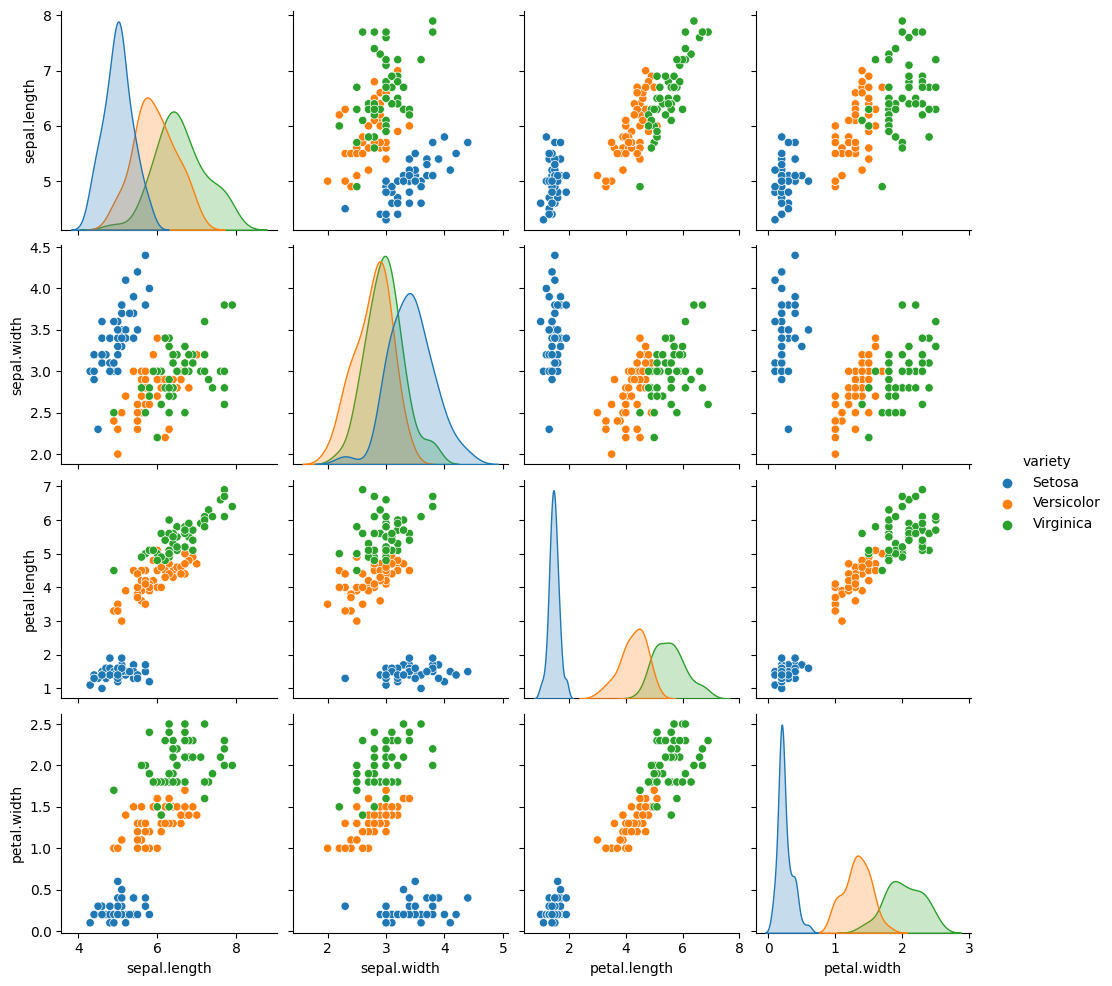

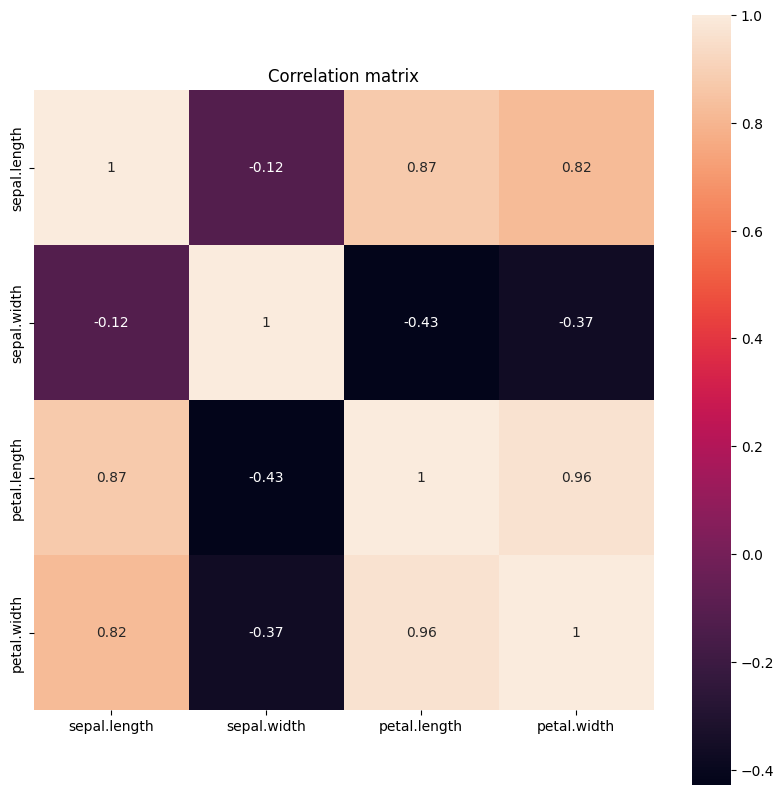

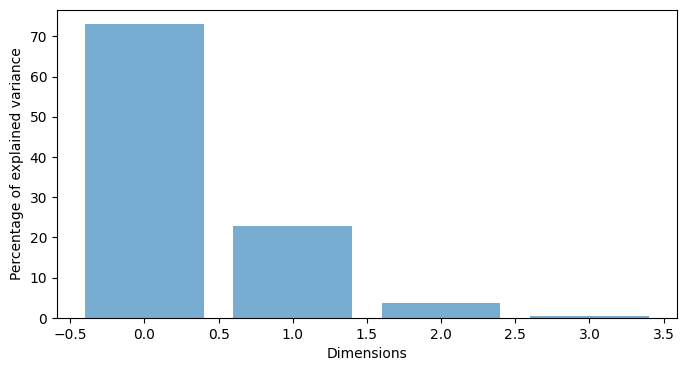

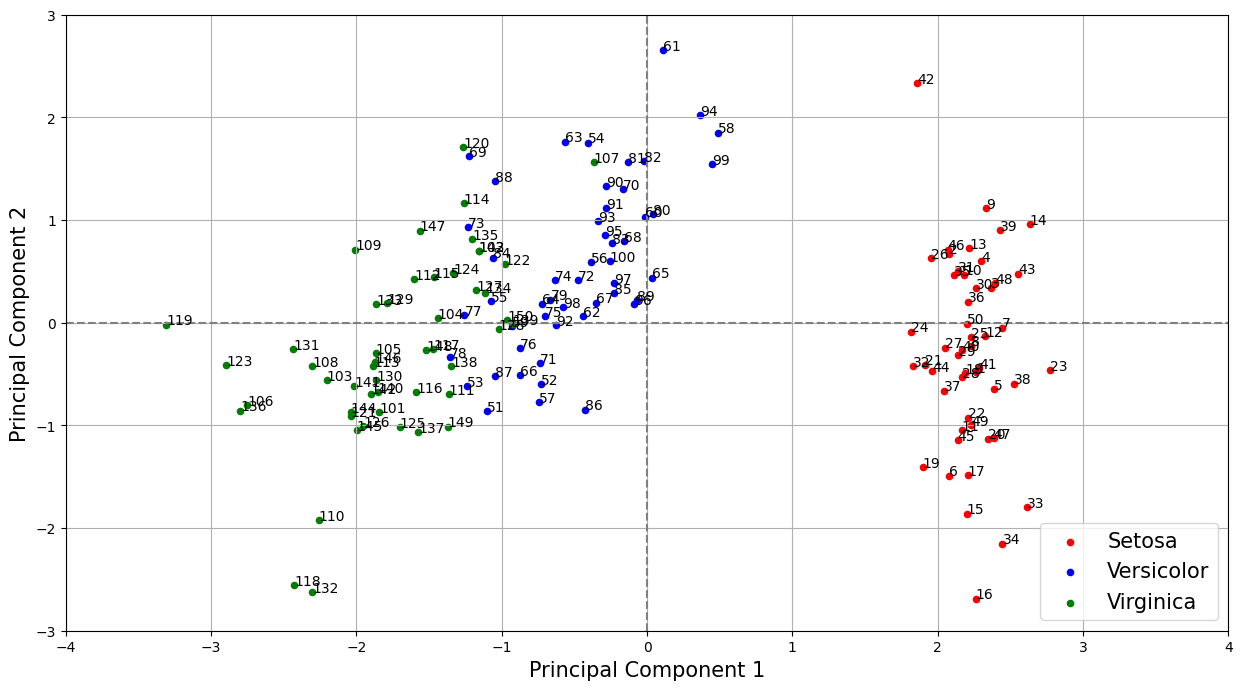

Confusion matrix: 
 [[-0.35214508  2.56822015 -0.49871624]
 [ 1.71702899 -0.15758189  0.25676564]
 [-1.36488391 -2.41063826  0.24195059]]
Accuracy =  0.6666666666666666


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Read csv data file, change to your location
df = pd.read_csv("D:\Code\Python\MachineLearning\Week_5\iris.csv")

df
df.describe()
sns.pairplot(df, hue = "variety")

# We're seperating the species column
species = df["variety"].tolist()
X = df.drop("variety", 1)
# Standardize the data
X = (X - X.mean()) / X.std(ddof=0)
# Calculating the correlation matrix of the data
X_corr = (1 / 150) * X.T.dot(X)
# Plotting the correlation matrix
plt.figure(figsize=(10,10))
sns.heatmap(X_corr, vmax=1, square=True,annot=True)
plt.title('Correlation matrix')

# method1
u,s,v = np.linalg.svd(X_corr)
eig_values, eig_vectors = s, u
eig_values, eig_vectors
# method2
np.linalg.eig(X_corr)

# plotting the variance explained by each PC 
explained_variance=(eig_values / np.sum(eig_values))*100
plt.figure(figsize=(8,4))
plt.bar(range(4), explained_variance, alpha=0.6)
plt.ylabel('Percentage of explained variance')
plt.xlabel('Dimensions')

pc1 = X.dot(eig_vectors[:,0])
pc2 = X.dot(eig_vectors[:,1])

# plotting in 2D
def plot_scatter(pc1, pc2):
    fig, ax = plt.subplots(figsize=(15, 8))
 
    species_unique = list(set(species))
    species_colors = ["r","b","g"]
 
    for i, spec in enumerate(species):
        plt.scatter(pc1[i], pc2[i], label = spec, s = 20, c=species_colors[species_unique.index(spec)])
        ax.annotate(str(i+1), (pc1[i],pc2[i]))
 
    from collections import OrderedDict
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), prop={'size': 15}, loc=4)
 
    ax.set_xlabel('Principal Component 1', fontsize = 15)
    ax.set_ylabel('Principal Component 2', fontsize = 15)
    ax.axhline(y=0, color="grey", linestyle="--")
    ax.axvline(x=0, color="grey", linestyle="--")
 
    plt.grid()
    plt.axis([-4, 4, -3, 3])
    plt.show()
 
plot_scatter(pc1, pc2)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = np.array([pc1,pc2]).T
y = species = df["variety"].tolist()

from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(df.variety)
df["variety"]=le.transform(df.variety)

y = np.array(df["variety"])

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, shuffle = False)
Xbar = np.concatenate((np.ones((X_train.shape[0], 1)), X_train), axis=1)

LogReg = LogisticRegression(max_iter = 1000, fit_intercept = False)
LogReg.fit(Xbar, y_train)
Xtest = np.concatenate((np.ones((X_test.shape[0], 1)), X_test), axis=1)
y_pred = LogReg.predict(Xtest)
print("Confusion matrix: \n", str(LogReg.coef_))
print("Accuracy = ", accuracy_score(y_test, y_pred))

Ví dụ 2:

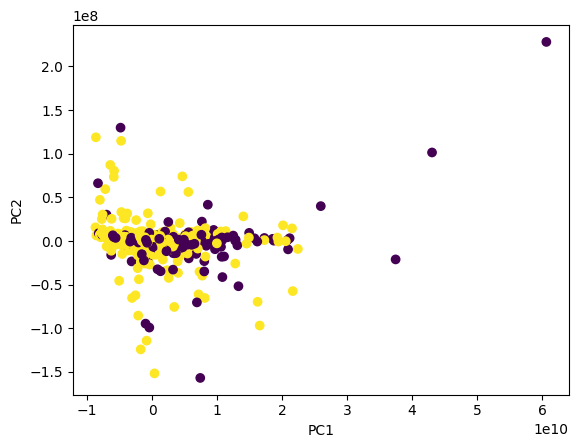

Accuracy: 0.672


In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
data = pd.read_csv("D:\Code\Python\MachineLearning\Week_5\pd_speech_features.csv")
data.head()

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

pca = PCA(n_components=200)
X_pca = pca.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.33, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Ví dụ 3:

In [6]:
import numpy as np
import gzip
from time import time
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Đọc dữ liệu ảnh từ file
with gzip.open('train-images-idx3-ubyte.gz', 'rb') as f:
    images = np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 28*28)

# Đọc nhãn từ file
with gzip.open('train-labels-idx1-ubyte.gz', 'rb') as f:
    labels = np.frombuffer(f.read(), np.uint8, offset=8)

# Lấy một tập dữ liệu con gồm 5000 ảnh bất kỳ
np.random.seed(42)
idx = np.random.choice(images.shape[0], size=5000, replace=False)
images = images[idx]
labels = labels[idx]

# Tạo các bộ dữ liệu đã qua giảm chiều và chưa qua giảm chiều với tỉ lệ train:validation là 0.7:0.3
pca = PCA(n_components=100)
images_reduced = pca.fit_transform(images)
X_train, X_val, y_train, y_val = train_test_split(images_reduced, labels, test_size=0.3, random_state=42)
X_train_orig, X_val_orig, y_train_orig, y_val_orig = train_test_split(images, labels, test_size=0.3, random_state=42)

# Huấn luyện và đánh giá độ chính xác trên dữ liệu đã qua giảm chiều
clf = LogisticRegression(multi_class='multinomial', solver='lbfgs')
start_time = time()
clf.fit(X_train, y_train)
train_time_pca = time() - start_time
start_time = time()
y_pred = clf.predict(X_val)
test_time_pca = time() - start_time
accuracy_pca = accuracy_score(y_val, y_pred)

# Huấn luyện và đánh giá độ chính xác trên dữ liệu nguyên bản
clf_orig = LogisticRegression(multi_class='multinomial', solver='lbfgs')
start_time = time()
clf_orig.fit(X_train_orig, y_train_orig)
train_time_orig = time() - start_time
start_time = time()
y_pred_orig = clf_orig.predict(X_val_orig)
test_time_orig = time() - start_time
accuracy_orig = accuracy_score(y_val_orig, y_pred_orig)

print(f'Accuracy on PCA-reduced data: {accuracy_pca:.2f} (train time: {train_time_pca:.2f}s, test time: {test_time_pca:.2f}s)')
print(f'Accuracy on original data: {accuracy_orig:.2f} (train time: {train_time_orig:.2f}s, test time: {test_time_orig:.2f}s)')

Accuracy on PCA-reduced data: 0.85 (train time: 0.17s, test time: 0.00s)
Accuracy on original data: 0.87 (train time: 0.92s, test time: 0.01s)
